# Reagan Sanz- Final Project
Example outputs of the notebook running can be seen in ./outputs (note that mp4s must be downloaded to view)  

**Instructions for Running**
- *0. Setup*: Set parameters by changing top box. Pick between u, v, or w for wind directions, and choose a start and end month/day. These months are in the form Jan, Feb, ..., Dec (3 characters long, capitalized).
- *1. Load Datasets*: Used in loading data from the Dyamond 3 dataset and calculating time conversions for the timestamps
- *2. Creates the Cropped Map*: **This is the bulk of the code.** It takes the data from Dyamond, graphs each day, applies a Cartopy image of the USA overlay, and crops to the region selected. **_NOTE_: This will take 1 minute PER "day" of data graphed**. Therefore, if testing the data, I suggest making the start and end dates very short.
- *3. Create MP4 of Data*: This creates a MP4 from the previous step's data. Note that Jupytr will not display the video. It must be downloaded to view.
- *4. View Data Directly in Notebook*: Does the same thing as Step 3, but just uses plt.show to show each image directly in the notebook. It's a bit buggy though.
- *5. View a single "snapshot"*: This part will display a single day/hour (as set by start_mo and start_day). It's variables can be altered in this box.
- *6. Graph Mean Velocities of Wind Speeds in Valley vs. Mountains*: Displays a graph (and saves it to ./outputs), showing the impact of the Smoky Mountains on Wind Velocities. 


## 0. Setup ##

### SELECT PARAMETERS (time/date range, wind direction, etc) ###

In [31]:
# Variable Choices
variable = 'w' # u: East-West Winds, v: North-South Winds, or w: upwards velocity (others p: pressure, T: temp)
region = "NC/TN" # Select region. Options: "NC/TN" or "Coast"

# Start and End Dates
start_mo = "Oct" # Options are all months Jan-Dec, and then Jan_26 and Feb_26
start_day = 15  #7
end_mo = "Oct"
end_day = 19



# KEEP ELEVATIONS CONSTANT (v_min and v_max are currently aligned to these specific altitudes)
# Start and End Elevations (Kept at 40, 47 in my experiment) 
el_min = 40   # Start elevation: 0 through 52, representing height above the surface
el_max = 47   # End elevation
el_mean = (el_min + el_max) / 2

# DONT TOUCH code below 
# Min and Max of colorbar, calculated for each variable
if variable == 'u':
    if( el_mean > 30):
        v_min = -20
        v_max = 20
    elif (el_mean >= 20):
        v_min = -40
        v_max = 40
    elif (el_mean < 20):
        v_min = -40
        v_max = 40
elif variable == 'v':
    v_min = -20
    v_max = 20
elif variable == 'w':
    v_min = -2
    v_max = 2
elif variable == 'p':
    v_min = 30000
    v_max = 200000
elif variable == 'T':
    v_min = -50
    v_max = 150
else:
    print("Invalid Variable")

print(f"v_min: {v_min}, v_max: {v_max}") 


v_min: -2, v_max: 2


### Install Requirements ###

In [32]:
!pip install --user cartopy
!pip install --user opencv-python
!pip install --user ipywidgets
%matplotlib inline


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


### Import Libraries, Set URL for Dyamond Data ###

In [33]:
# Import Libraries 
import numpy as np
import OpenVisus as ov
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.feature as cfeature # See reference [1], used for state boarders 
import cartopy.crs as ccrs
from cartopy.io import shapereader # For cities in Cartopy
import time # for slowing down iterations through timestamps
import cv2
import os


# Set Variable
base_url= "https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/"
face=4
timestep=1
base_dir=f"https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_{variable.upper()}/{variable.lower()}_face_{face}_depth_52_time_0_10269.idx"
field = base_dir
if variable == 'u':
    wind_direction = "West-to-East"
elif variable == 'v':
    wind_direction = "North-to-South"
elif variable == 'w':
    wind_direction = "Rising/Falling (Vertical)"


## 1. Load Dataset ##

### 1.1 Load Dataset, Label Map with Cartopy State lines/cities ###

In [34]:
# Load Dyamond 3 dataset
db = ov.LoadDataset(field)
print(f'Dimensions: {db.getLogicBox()[1][0]}*{db.getLogicBox()[1][1]}*{db.getLogicBox()[1][2]}')
print(f'Total Timesteps: {len(db.getTimesteps())}')
print(f'Field: {db.getField().name}')
print('Data Type: float32')

# Read data, quality is reduced to -1 to capture TN bettter
#data = db.read(time=0, quality=0, z=[el_min, el_max])

# For adding cities to the map
shpfilename = shapereader.natural_earth(resolution='10m', category='cultural', name='populated_places')
reader = shapereader.Reader(shpfilename)
cities = reader.records()
cities_list = list(reader.records())

# Timestamp -> month conversion
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan (26)", "Feb (26)"]
timestamps = [744, 1416, 2160, 2880, 3624, 4344, 5088, 5832, 6552, 7296, 8016, 8760, 10269]
day = 0
hour = 0

Dimensions: 1440*1440*52
Total Timesteps: 10269
Field: w
Data Type: float32


### 1.2 Convert Month/Day to timestamp value ###

In [35]:
# Code for calculating date/time
month_ranges = {
    "Jan": (0, 263),           #Jan 20 through Jan 31 (11 days)
    "Feb": (264, 935),         
    "Mar": (936, 1679),       
    "Apr": (1680, 2399),       
    "May": (2400, 3143),
    "Jun": (3144, 3863),
    "Jul": (3864, 4607),
    "Aug": (4608, 5351),
    "Sep": (5352, 6071),
    "Oct": (6072, 6815),
    "Nov": (6816, 7535),
    "Dec": (7536, 8279),
    "Jan_26": (8280, 9023),
    "Feb_26": (9024, 9695)
}

def setStartAndEnd(cur_start_mo, cur_end_mo, cur_start_day, cur_end_day):
    # Start and end
    (start_t, _) = month_ranges[cur_start_mo]
    (_, end_t) = month_ranges[cur_end_mo]
    
    # Calc start based on start_day
    month_start = month_ranges[cur_start_mo][0]
    day_offset = (cur_start_day - 1) * 24  
    start_t = month_start + day_offset
    
    # Calc end based on end_day
    month_end_start = month_ranges[cur_end_mo][0]
    day_offset_end = cur_end_day * 24 
    end_t = month_end_start + day_offset_end
    
    return start_t, end_t

start_t, end_t = setStartAndEnd(start_mo, end_mo, start_day, end_day)
print(f"Start: {start_t}, End: {end_t}") 

def setDateTime(t):
    for month, (start, end) in month_ranges.items(): #iterate through month ranges 
        if start <= t <= end:
            cur_mon = month
            
            # Calculate Day/Hour relative to that month's start
            rel_t = t - start
            if month == "Jan": #specicial case with shortened Jan
                day = (rel_t // 24) + 20
            else:
                day = (rel_t // 24) + 1
                
            hour = (rel_t % 24) + 1
            break
    return (day, hour, cur_mon)

def plotDot(target_lon, target_lat):
    # Hurricane
    #target_lon = -54.4  # West is negative
    #target_lat = 20.4 

    ax.plot(target_lon, target_lat, 'ro', markersize=8, transform=ccrs.PlateCarree(), zorder=15)

    # Add a label if you want
    ax.text(target_lon + 0.5, target_lat + 0.5, "Hurricane", transform=ccrs.PlateCarree(), color='red', fontweight='bold')
    

Start: 6408, End: 6528


## 2. Use GEOS dataset on the map, Crop it to South-East Region

### Creates Image files of wind directions for NC/TN and saves them
*NOTE:* This will take **AWHILE** to run (about ~1 minute per "day" of data)

In [36]:
print(f"V_min: {v_min}, V_max: {v_max}")
data = db.read(time=start_t, quality=0, z=[el_min, el_max]) # read data
for t in range(start_t, end_t):
    #t = start_t
    
    # Plot the map
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add timestamp
    day, hour, cur_mon = setDateTime(t)
    
    # Plot the text containing the current date/time
    plt.text(0.02, 0.95, f"Time: {cur_mon}- Day {day}, Hour {hour}, Elevation: {el_min}-{el_max}", transform=ax.transAxes, 
        fontsize=12, 
        fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        zorder=12)
    
    # Add Coastline and state lines to map
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
    
    #plotDot() #optional
    
    # Just plot cities around East TN region
    for city in cities_list:
        if city.attributes['NAME'] in ['Knoxville', 'Asheville', 'Charlotte']:
            x, y = city.geometry.x, city.geometry.y
            ax.plot(x, y, 'ko', transform=ccrs.PlateCarree())
            ax.text(x + 0.1, y + 0.1, city.attributes['NAME'], transform=ccrs.PlateCarree())
 
    
    local_slice = data[0, :, :] if data.ndim==3 else data
    local_slice = np.rot90(local_slice, k=1)
            
    # Set imshow to the bounds of Face 4 from the GEOS dataset
    im = ax.imshow(local_slice, 
        origin='lower', 
        extent=[-161, -49, -38, 42],  #NEW: Coords of Face 4: [-160, -50, -38, 42]
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        vmin = v_min,
        vmax = v_max)
                  # vmin=-20, # 0.07 for surface
                   #vmax=20)
    
    # Cropping the map
    if region == "NC/TN":
        ax.set_extent([-86, -80, 34, 37], crs=ccrs.PlateCarree()) # Just TN/NC region
    elif region == "Coast":
        ax.set_extent([-95, -50, 10, 42], crs=ccrs.PlateCarree()) # South East USA, including coast 
    else:
        ax.set_extent([-161, -49, -38, 42],  crs=ccrs.PlateCarree())
    
    # Plot 
    plt.colorbar(im, label='Wind Speed (m/s)', orientation='horizontal', pad=0.08)
    plt.title(f"East TN region: {wind_direction} Wind Velocities")
    plt.savefig(f"./images/{cur_mon}/{cur_mon}_{variable}_{day}_{hour}.png")
    #plt.show()
    plt.close(fig)
    
    # Rest before displaying next timestamp
    #time.sleep(0.05)
    hour+= 1
    data = db.read(time=t, quality=0, z=[el_min, el_max]) # read data



V_min: -2, V_max: 2


## 3. Convert Saved PNGs to a viewable MP4

### 3.1 Iterate through image data and save to a video file ###
NOTE: Videos are saved to ./outputs.
These must be downloaded to be viewed (cannot be viewed within notebook)

In [37]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def convert_images_to_video(output_file, fps):
    start_idx = month_order.index(start_mo)
    end_idx = month_order.index(end_mo) + 1

    ordered_imgs = []

    # Order the images by month/day/hour to be turned into a video
    for i, mo in enumerate(month_order[start_idx:end_idx]):
        input_folder = f"./images/{mo}"
        
        # Get number of days per month using month ranges
        start_h, end_h = month_ranges[mo]
        num_days = ((end_h - start_h + 1) // 24)

        # Set days (d) and hours (h) in order
        for d in range(1, num_days + 1):
            # Checking if first or last month / day
            if i == 0 and d < start_day:
                continue
            if i == (end_idx - start_idx - 1) and d > end_day:
                break
                
            for h in range(1, 25):        
                full_path = os.path.join(input_folder, f"{mo}_{variable}_{d}_{h}.png")
                
                if os.path.exists(full_path):
                    ordered_imgs.append(full_path)
        
    # Read image to get its dimensions
    test_image = cv2.imread(ordered_imgs[0])
    height, width, _ = test_image.shape

    # Create a VideoWriter object to save the video
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # mp4v for saving to computer, 'avc1' for displaying in Jupytr
    video = cv2.VideoWriter(output_file, fourcc, fps, (width, height))

    # Iterate over each image and write it to the video
    for image_file in ordered_imgs:
        frame = cv2.imread(image_file)
        if frame is None:
            print(f"Failed to load: {image_file}")
            continue
        video.write(frame)

    # Release the video writer and close the video file
    video.release()
    cv2.destroyAllWindows()

    return width

# Path to output video file and set FPS
output_file = f"./outputs/output_{start_mo}_to_{end_mo}.mp4"
fps = 24  # Frames per second

print("Creating MP4 of data...")
# Call the function to convert the images to video
width = convert_images_to_video(output_file, fps)

print("Done! Saved to ./outputs")

Creating MP4 of data...
Done! Saved to ./outputs


## 4. View Screenshots in Jupyter Notebook ##
Note: Can be a bit buggy at times

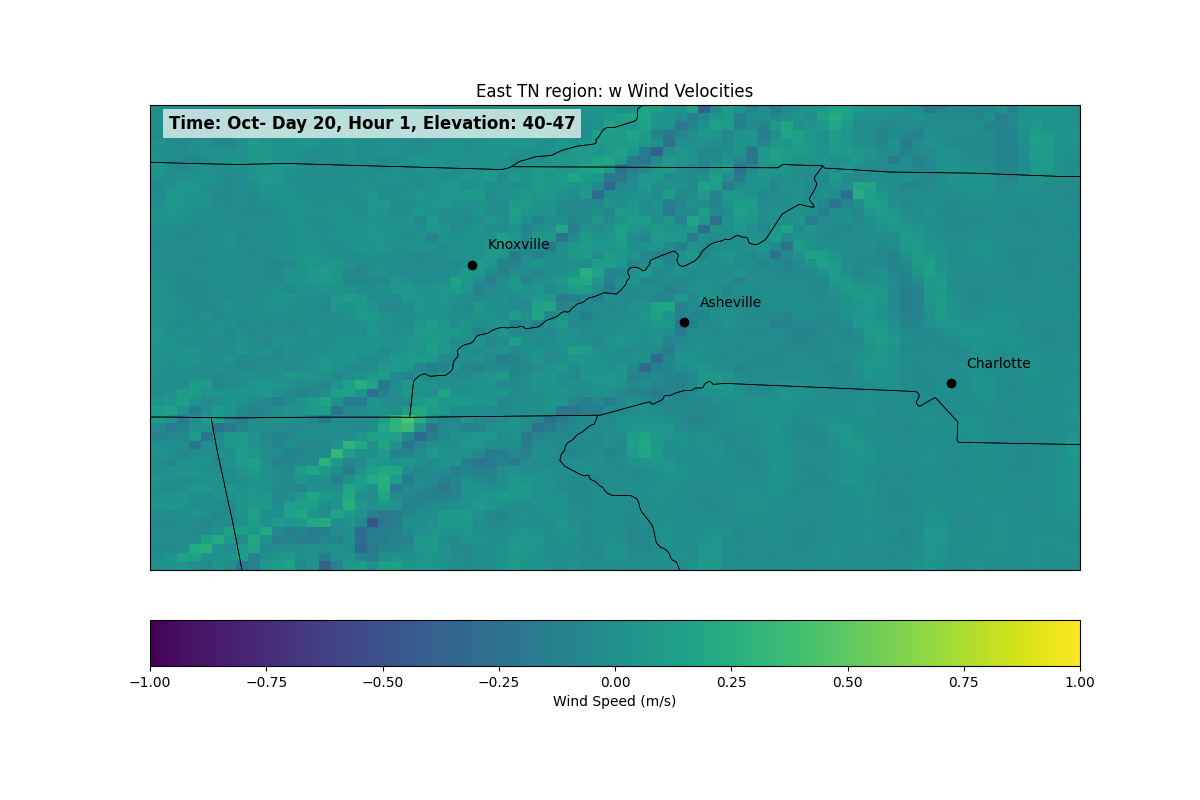

In [38]:
from IPython.display import display, Image, clear_output
import time

# For viewing PNG outputs as a "video" in Jupyter Notebook
def jupyter_viewer(start, end, variable="U"):
    dh = display(display_id=True)
    for t in range(start, end + 1):
        # Iterate through month, hour, and day in order
        for month, (m_start, m_end) in month_ranges.items():
            if m_start <= t <= m_end:
                cur_mon = month
                rel_t = t - m_start
                day = (rel_t // 24) + 1
                hour = (rel_t % 24) + 1
                break
        
        img_path = f"./images/{cur_mon}/{cur_mon}_{variable}_{day}_{hour}.png"

        # Check if path exists and show each slide in notebook
        if os.path.exists(img_path):
            clear_output(wait=True)
            #print(f"Viewing: {cur_mon} Day {day} Hour {hour} (t={t})")
            dh.update(Image(filename=img_path, width=800))
            
            # Adjust as needed for speed
            time.sleep(0.1) 
        else:
            continue

# Printing each img back-to-back
jupyter_viewer(start_t, end_t, variable)

## 5. View Individual Day with set precision ##
For viewing a single day with specific v_min/v_max or set elevation

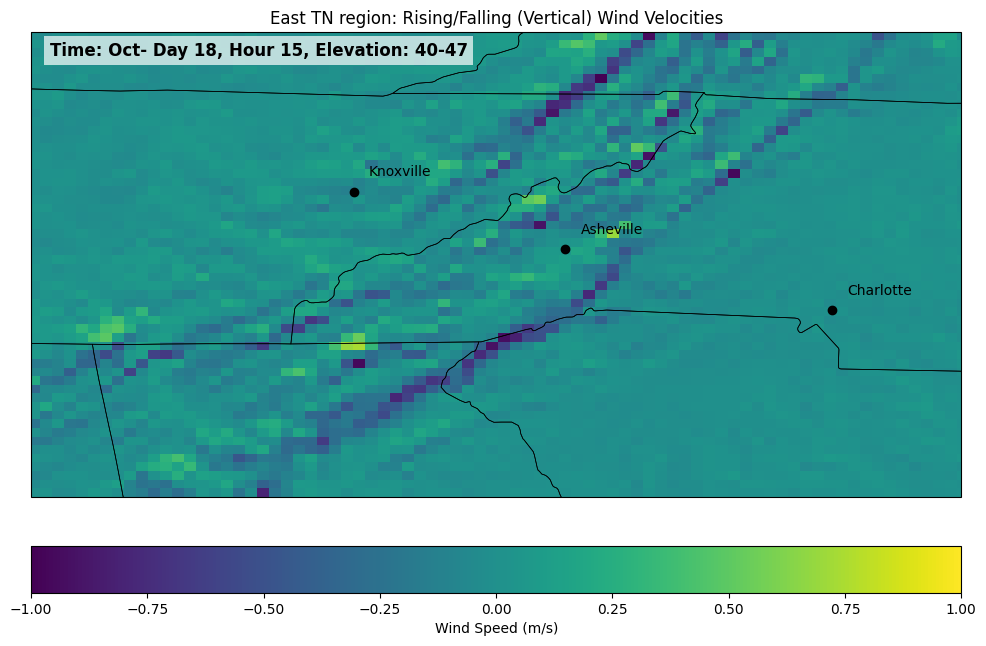

In [39]:
def single_day_display(ex_el_min, ex_el_max, ex_v_min, ex_v_max, cur_mo, cur_day, cur_hour, capture_timestamp, cur_region):
    t = capture_timestamp + cur_hour - 1
    data = db.read(time=t, quality=0, z=[el_min, el_max]) # read data
    
    # Plot the map
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add timestamp
    day, hour, cur_mon = setDateTime(t)
    
    # Plot the text containing the current date/time
    plt.text(0.02, 0.95, f"Time: {cur_mon}- Day {day}, Hour {hour}, Elevation: {el_min}-{el_max}", transform=ax.transAxes, 
        fontsize=12, 
        fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        zorder=12)
    
    # Add Coastline and state lines to map
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
    
    # Just plot cities around East TN/NC region
    for city in cities_list:
        if city.attributes['NAME'] in ['Knoxville', 'Asheville', 'Charlotte']:
            x, y = city.geometry.x, city.geometry.y
            ax.plot(x, y, 'ko', transform=ccrs.PlateCarree())
            ax.text(x + 0.1, y + 0.1, city.attributes['NAME'], transform=ccrs.PlateCarree())
 
    local_slice = data[0, :, :] if data.ndim==3 else data
    local_slice = np.rot90(local_slice, k=1)
            
    # Set imshow to the bounds of Face 4 from the GEOS dataset
    im = ax.imshow(local_slice, 
        origin='lower', 
        extent=[-161, -49, -38, 42],  #NEW: Coords of Face 4: [-160, -50, -38, 42]
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        vmin = ex_v_min,
        vmax = ex_v_max)
    
    # Cropping the map
    if cur_region == "NC/TN":
        ax.set_extent([-86, -80, 34, 37], crs=ccrs.PlateCarree()) # Just TN/NC region
    elif cur_region == "Coast":
        ax.set_extent([-95, -50, 10, 42], crs=ccrs.PlateCarree()) # South East USA, including coast 
    else:
        ax.set_extent([-161, -49, -38, 42],  crs=ccrs.PlateCarree())
    
    # Plot 
    plt.colorbar(im, label='Wind Speed (m/s)', orientation='horizontal', pad=0.08)
    plt.title(f"East TN region: {wind_direction} Wind Velocities")
    plt.show()
    
    hour+= 1
    data = db.read(time=t, quality=0, z=[el_min, el_max]) # read data

# Variables (change these as needed)
el_min = 40 # elevation min/max
el_max = 47
min_v = -1  # min and max for color bar. -20/20 is good for u/v, -1/1 is good for w
max_v = 1
cur_mo = "Oct" #Current month, day, hour
cur_day = 18
cur_hour = 15
cur_region = "NC/TN" #options: NC/TN or Coast

capture_timestamp, _ = setStartAndEnd(cur_mo, end_mo, cur_day, end_day)
single_day_display(el_min, el_max, min_v, max_v, cur_mo, cur_day, cur_hour, capture_timestamp, cur_region)


## 6. Graph for Mean Velocities in Valley vs. Mountains ##
Graph also saved to ./outputs

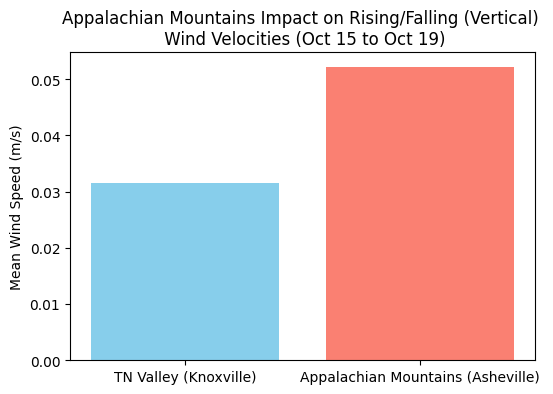

In [44]:
valley_coords = [-84.5, -83.5, 35.5, 36.5]   # Knoxville/Valley area
mountain_coords = [-83.0, -82.0, 35.0, 36.0] # Asheville/Mountain area
fv = [-161, -49, -38, 42] 

valley_means_list = []
mountain_means_list = []

# Convert coords into array indices
def geo_to_index(lon, lat, full_extent, shape):
    lon_range = full_extent[1] - full_extent[0]
    lat_range = full_extent[3] - full_extent[2]
    x_idx = int((lon - full_extent[0]) / lon_range * shape[1])
    y_idx = int((lat - full_extent[2]) / lat_range * shape[0])
    return x_idx, y_idx

# Iterate through date range
for t in range(start_t, end_t):
    # Map to array indicies 
    vx1, vy1 = geo_to_index(valley_coords[0], valley_coords[2], fv, local_slice.shape)
    vx2, vy2 = geo_to_index(valley_coords[1], valley_coords[3], fv, local_slice.shape)
    mx1, my1 = geo_to_index(mountain_coords[0], mountain_coords[2], fv, local_slice.shape)
    mx2, my2 = geo_to_index(mountain_coords[1], mountain_coords[3], fv, local_slice.shape)
    
    # Get data slices to find means of valley vs mountain
    valley_mean = np.mean(np.abs(local_slice[vy1:vy2, vx1:vx2]))
    mountain_mean = np.mean(np.abs(local_slice[my1:my2, mx1:mx2]))

    # Push into lists
    valley_means_list.append(valley_mean)
    mountain_means_list.append(mountain_mean)

# Total up means
total_valley_mean = np.mean(valley_means_list)
total_mountain_mean = np.mean(mountain_means_list)

# Bar chart for comparison of Valley v Mountains Winds
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['TN Valley (Knoxville)', 'Appalachian Mountains (Asheville)'], [total_valley_mean, total_mountain_mean], color=['skyblue', 'salmon'])
ax.set_ylabel('Mean Wind Speed (m/s)')
ax.set_title(f'Appalachian Mountains Impact on {wind_direction} \n Wind Velocities ({start_mo} {start_day} to {end_mo} {end_day})')
plt.savefig(f"./outputs/Wind_Velocities_Comparison_{day}_{hour}.png")
plt.show()
plt.close()